In [1]:
import pandas as pd

In [2]:
df = pd.read_parquet("out/DATA_PRP_5C/PRP1_C5_P2_V1_T2_S1/parquets/220ecd_fobs.parquet")

In [27]:
df_clean = df.query("value > 0.1").copy()
# df_clean = df.copy()

In [38]:
df_clean.query("var == 'Z'")

,hash_file,var,t,p,v,i,k,j,value
5,220ecd3f60295cc52ee365a65661b24e583dadb6,Z,0,NaN,0.0,0.0,5.0,NaN,1.0
12,220ecd3f60295cc52ee365a65661b24e583dadb6,Z,0,NaN,0.0,2.0,0.0,NaN,1.0
20,220ecd3f60295cc52ee365a65661b24e583dadb6,Z,0,NaN,0.0,3.0,2.0,NaN,1.0
33,220ecd3f60295cc52ee365a65661b24e583dadb6,Z,0,NaN,0.0,5.0,3.0,NaN,1.0
40,220ecd3f60295cc52ee365a65661b24e583dadb6,Z,0,NaN,1.0,0.0,4.0,NaN,1.0
60,220ecd3f60295cc52ee365a65661b24e583dadb6,Z,0,NaN,1.0,4.0,0.0,NaN,1.0
74,220ecd3f60295cc52ee365a65661b24e583dadb6,Z,1,NaN,0.0,0.0,2.0,NaN,1.0
78,220ecd3f60295cc52ee365a65661b24e583dadb6,Z,1,NaN,0.0,1.0,0.0,NaN,1.0
85,220ecd3f60295cc52ee365a65661b24e583dadb6,Z,1,NaN,0.0,2.0,1.0,NaN,1.0
113,220ecd3f60295cc52ee365a65661b24e583dadb6,Z,1,NaN,1.0,0.0,5.0,NaN,1.0


In [29]:
df_clean.query("var == 'R'")

,hash_file,var,t,p,v,i,k,j,value
269,220ecd3f60295cc52ee365a65661b24e583dadb6,R,0,0.0,0.0,0.0,5.0,NaN,227.0
284,220ecd3f60295cc52ee365a65661b24e583dadb6,R,0,0.0,0.0,3.0,2.0,NaN,56.0
297,220ecd3f60295cc52ee365a65661b24e583dadb6,R,0,0.0,0.0,5.0,3.0,NaN,139.0
305,220ecd3f60295cc52ee365a65661b24e583dadb6,R,0,1.0,0.0,0.0,5.0,NaN,50.0
320,220ecd3f60295cc52ee365a65661b24e583dadb6,R,0,1.0,0.0,3.0,2.0,NaN,34.0
333,220ecd3f60295cc52ee365a65661b24e583dadb6,R,0,1.0,0.0,5.0,3.0,NaN,50.0
340,220ecd3f60295cc52ee365a65661b24e583dadb6,R,0,0.0,1.0,0.0,4.0,NaN,115.0
376,220ecd3f60295cc52ee365a65661b24e583dadb6,R,0,1.0,1.0,0.0,4.0,NaN,161.0
410,220ecd3f60295cc52ee365a65661b24e583dadb6,R,1,0.0,0.0,0.0,2.0,NaN,154.0
421,220ecd3f60295cc52ee365a65661b24e583dadb6,R,1,0.0,0.0,2.0,1.0,NaN,93.0


In [30]:
df_clean['var'].unique()

array(['Z', 'X', 'Y', 'I', 'R', 'Q', 'P'], dtype=object)

In [39]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import numpy as np

def build_graphs_by_time(df_clean):
    """
    Constrói um grafo para cada intervalo de tempo t.
    
    Args:
        df_clean: DataFrame com variáveis Z, R, Q, I indexadas por t, v, p, i, k
        
    Returns:
        dict: Dicionário com grafos por tempo {t: G}
    """
    graphs = {}
    
    # Agrupar por tempo
    for t, df_t in df_clean.groupby('t'):
        G = nx.DiGraph()
        
        # Adicionar arestas baseado em Z (veículo usou a aresta)
        df_z = df_t[df_t['var'] == 'Z']
        
        for _, row in df_z.iterrows():
            i = row['i']  # nó origem
            k = row['k']  # nó destino
            v = row['v']  # veículo
            
            if row['value'] > 0.5:  # Z é binária
                # Buscar TODOS os valores de R para esta aresta (i, k, v)
                # R tem índices (t, v, i, k, p), então temos múltiplas linhas - uma por produto
                df_r = df_t[(df_t['var'] == 'R') & 
                           (df_t['i'] == i) & 
                           (df_t['k'] == k) & 
                           (df_t['v'] == v)].reset_index(drop=True)
                
                # Adicionar aresta se ainda não existe
                if not G.has_edge(i, k):
                    G.add_edge(i, k, vehicles=[], colors=[], weights_r=[], products=[])
                
                # Para cada produto nesta aresta, adicionar à lista
                if df_r.empty:
                    # Se não houver R para esta aresta, ainda assim adicionamos a aresta com peso 0
                    G[i][k]['vehicles'].append(v)
                    G[i][k]['colors'].append('blue' if v == 0 else 'red')
                    G[i][k]['weights_r'].append(0)
                    G[i][k]['products'].append(None)
                for x, r_row in df_r.iterrows():
                    p = r_row['p']  # produto (vem de R)
                    weight_r = r_row['value']  # valor de R
                    
                    # Definir cor baseado no veículo
                    color = 'blue' if v == 0 else 'red'
                    
                    # if x == 0:
                    G[i][k]['vehicles'].append(v)
                    G[i][k]['colors'].append(color)
                    G[i][k]['weights_r'].append(weight_r)
                    G[i][k]['products'].append(p)
        
        # Adicionar pesos dos nós (Q e I)
        nodes_data = {}
        for node in G.nodes():
            nodes_data[node] = {'Q': {}, 'I': {}}
        
        # Q: quanto o nó recebeu de cada produto
        df_q = df_t[df_t['var'] == 'Q']
        for _, row in df_q.iterrows():
            i = row['i']
            p = row['p']
            if i not in nodes_data:
                nodes_data[i] = {'Q': {}, 'I': {}}
            nodes_data[i]['Q'][p] = row['value']
        
        # I: estoque no nó de cada produto
        df_i = df_t[df_t['var'] == 'I']
        for _, row in df_i.iterrows():
            i = row['i']
            p = row['p']
            if i not in nodes_data:
                nodes_data[i] = {'Q': {}, 'I': {}}
            nodes_data[i]['I'][p] = row['value']
        
        # Adicionar nodes com atributos
        for node, attrs in nodes_data.items():
            if node not in G:
                G.add_node(node)
            G.nodes[node]['Q'] = attrs['Q']
            G.nodes[node]['I'] = attrs['I']
        
        graphs[t] = G
    
    return graphs

# Construir os grafos
graphs = build_graphs_by_time(df_clean)
print(f"Total de grafos criados: {len(graphs)}")
print(f"Tempos disponíveis: {sorted(graphs.keys())}")

Total de grafos criados: 3
Tempos disponíveis: [0, 1, 2]


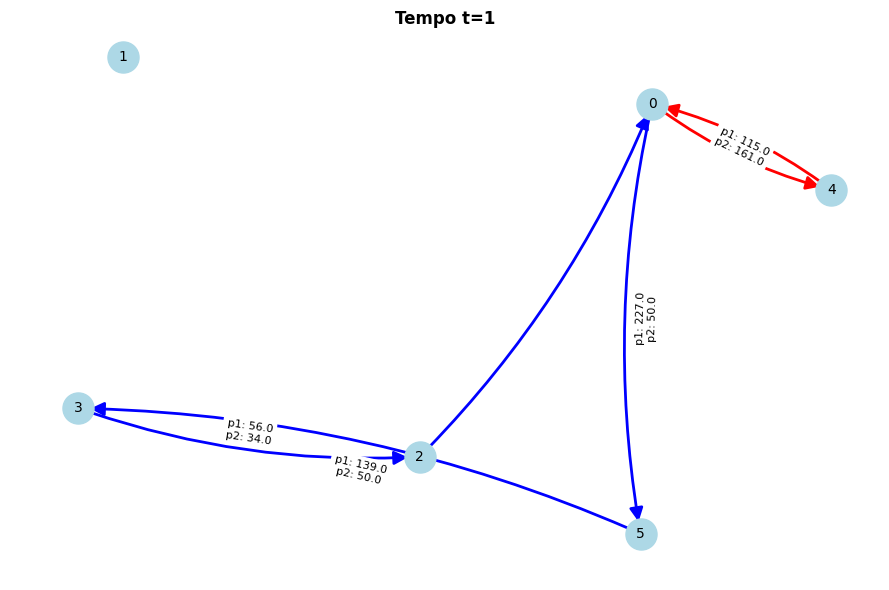

In [41]:
def visualize_graph(G, t, figsize=(9, 6)):
    """
    Visualiza um grafo com cores diferenciadas por veículo e informações de pesos.
    
    Args:
        G: Grafo networkx
        t: Tempo (para título)
        figsize: Tamanho da figura
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Layout do grafo
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    
    # Desenhar nodes com tamanho fixo
    nx.draw_networkx_nodes(G, pos, node_size=500, 
                          node_color='lightblue', ax=ax)
    
    # Desenhar arestas com cores por veículo e labels com pesos R por produto
    edge_labels = {}
    for color_name, color_hex in [('blue', '#0000FF'), ('red', '#FF0000')]:
        edges_to_draw = []
        for (i, k) in G.edges():
            if color_name in G[i][k]['colors']:
                edges_to_draw.append((i, k))
        
        if edges_to_draw:
            nx.draw_networkx_edges(G, pos, edgelist=edges_to_draw, 
                                  edge_color=color_hex, width=2, 
                                  ax=ax, arrows=True, 
                                  arrowsize=20, connectionstyle='arc3,rad=0.1')
    
    # Criar labels agrupando por aresta e produto
    for (i, k) in G.edges():
        edge_data = G[i][k]
        product_r = {}  # Dicionário para acumular R por produto
        
        # Agrupar R por produto
        for j, v in enumerate(edge_data['vehicles']):
            r_val = edge_data['weights_r'][j]
            p = edge_data['products'][j]
            
            if pd.notna(p):
                p_int = int(p) + 1
                if p_int not in product_r:
                    product_r[p_int] = 0
                product_r[p_int] += r_val
        
        # Criar label com produtos e seus valores de R
        if product_r:
            label_parts = [f"p{p}: {r:.1f}" for p, r in sorted(product_r.items())]
            edge_labels[(i, k)] = "\n".join(label_parts)
    
    # Desenhar labels das arestas
    if edge_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                                     font_size=8, ax=ax)
    
    # Labels dos nodes sem offset
    labels = {node: int(node) for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, ax=ax)
    
    ax.set_title(f"Tempo t={int(t)+1}", fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    return fig

# Visualizar o primeiro grafo como exemplo
if graphs:
    first_t = sorted(graphs.keys())[0]
    fig = visualize_graph(graphs[first_t], first_t)
    plt.show()

In [42]:
def inspect_graph(G, t):
    """
    Imprime informações detalhadas de um grafo.
    """
    print(f"\n{'='*60}")
    print(f"Grafo - Tempo t={int(t)+1}")
    print(f"{'='*60}")
    print(f"Nodes: {sorted(G.nodes())}")
    print(f"Arestas: {len(G.edges())}\n")
    
    print("NODES E SEUS PESOS:")
    for node in sorted(G.nodes()):
        print(f"\n  Node {node}:")
        q_data = G.nodes[node]['Q']
        i_data = G.nodes[node]['I']
        
        if q_data:
            print(f"    Q (Recebimento): {q_data}")
        else:
            print(f"    Q (Recebimento): vazio")
            
        if i_data:
            print(f"    I (Estoque): {i_data}")
        else:
            print(f"    I (Estoque): vazio")
    
    print("\n" + "="*60)
    print("ARESTAS E SEUS PESOS:")
    for (i, k) in sorted(G.edges()):
        edge_data = G[i][k]
        print(f"\n  Aresta ({i} → {k}):")
        
        # Agrupar por produto
        product_info = {}
        for j, v in enumerate(edge_data['vehicles']):
            r_val = edge_data['weights_r'][j]
            p = edge_data['products'][j]
            color = edge_data['colors'][j]
            
            if pd.notna(p):
                p_int = int(p) + 1
                v_int = int(v) + 1
                if p_int not in product_info:
                    product_info[p_int] = []
                product_info[p_int].append((v_int, color, r_val))
        
        # Imprimir agrupado por produto
        for p_int in sorted(product_info.keys()):
            total_r = sum(r_val for _, _, r_val in product_info[p_int])
            print(f"    Produto {p_int}: R={total_r:.2f}")
            for v_int, color, r_val in product_info[p_int]:
                print(f"      - Veículo {v_int} ({color}): {r_val:.2f}")

# Inspecionar todos os grafos
for t in sorted(graphs.keys()):
    inspect_graph(graphs[t], t)


Grafo - Tempo t=1
Nodes: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
Arestas: 6

NODES E SEUS PESOS:

  Node 0.0:
    Q (Recebimento): vazio
    I (Estoque): vazio

  Node 1.0:
    Q (Recebimento): vazio
    I (Estoque): {0.0: 11.0, 1.0: 14.0}

  Node 2.0:
    Q (Recebimento): {0.0: 56.0, 1.0: 34.0}
    I (Estoque): {0.0: 29.0}

  Node 3.0:
    Q (Recebimento): {0.0: 83.0, 1.0: 16.0}
    I (Estoque): vazio

  Node 4.0:
    Q (Recebimento): {0.0: 115.0, 1.0: 161.0}
    I (Estoque): {0.0: 89.0, 1.0: 100.0}

  Node 5.0:
    Q (Recebimento): {0.0: 88.0}
    I (Estoque): {0.0: 22.0, 1.0: 49.0}

ARESTAS E SEUS PESOS:

  Aresta (0.0 → 4.0):
    Produto 1: R=115.00
      - Veículo 2 (red): 115.00
    Produto 2: R=161.00
      - Veículo 2 (red): 161.00

  Aresta (0.0 → 5.0):
    Produto 1: R=227.00
      - Veículo 1 (blue): 227.00
    Produto 2: R=50.00
      - Veículo 1 (blue): 50.00

  Aresta (2.0 → 0.0):

  Aresta (3.0 → 2.0):
    Produto 1: R=56.00
      - Veículo 1 (blue): 56.00
    Produto 2: R=34.00

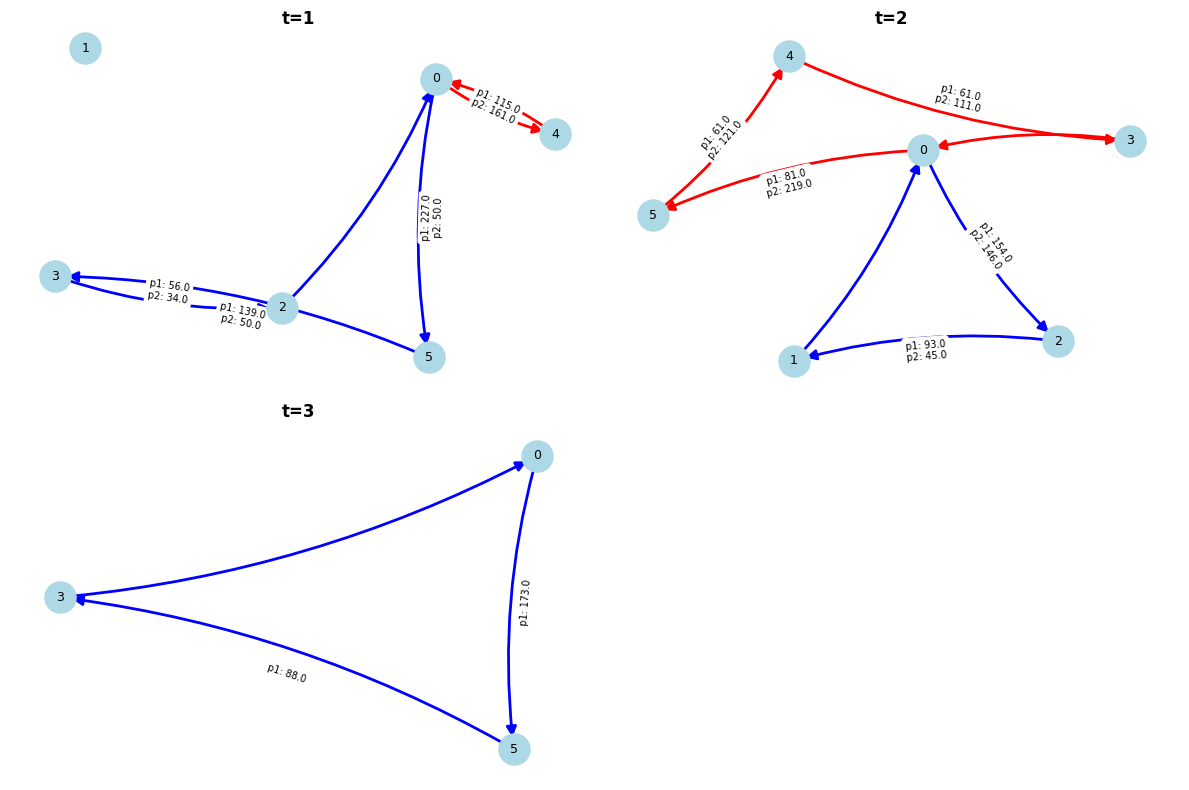

In [43]:
# Função auxiliar para visualizar múltiplos grafos
def visualize_all_graphs(graphs, max_cols=2):
    """
    Visualiza todos os grafos em um grid.
    """
    times = sorted(graphs.keys())
    n_graphs = len(times)
    n_cols = min(max_cols, n_graphs)
    n_rows = (n_graphs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
    if n_graphs == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, t in enumerate(times):
        ax = axes[idx]
        G = graphs[t]
        
        # Layout
        pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
        
        # Nodes com tamanho fixo
        nx.draw_networkx_nodes(G, pos, node_size=500, 
                              node_color='lightblue', ax=ax)
        
        # Edges por veículo (cores)
        for color_name, color_hex in [('blue', '#0000FF'), ('red', '#FF0000')]:
            edges = [(i, k) for (i, k) in G.edges() 
                    if color_name in G[i][k]['colors']]
            if edges:
                nx.draw_networkx_edges(G, pos, edgelist=edges, 
                                      edge_color=color_hex, width=2, ax=ax,
                                      arrows=True, arrowsize=15, 
                                      connectionstyle='arc3,rad=0.1')
        
        # Criar labels agrupando por aresta e produto
        edge_labels = {}
        for (i, k) in G.edges():
            edge_data = G[i][k]
            product_r = {}  # Dicionário para acumular R por produto
            
            # Agrupar R por produto
            for j, v in enumerate(edge_data['vehicles']):
                r_val = edge_data['weights_r'][j]
                p = edge_data['products'][j]
                
                if pd.notna(p):
                    p_int = int(p) + 1
                    if p_int not in product_r:
                        product_r[p_int] = 0
                    product_r[p_int] += r_val
            
            # Criar label com produtos e seus valores de R
            if product_r:
                label_parts = [f"p{p}: {r:.1f}" for p, r in sorted(product_r.items())]
                edge_labels[(i, k)] = "\n".join(label_parts)
        
        # Desenhar labels das arestas
        if edge_labels:
            nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                                         font_size=7, ax=ax)
        
        # Labels dos nodes
        labels = {node: int(node) for node in G.nodes()}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, ax=ax)
        ax.set_title(f"t={int(t)+1}", fontsize=12, fontweight='bold')
        ax.axis('off')
    
    # Remover axes não utilizados
    for idx in range(len(times), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    return fig

# Visualizar todos os grafos
if len(graphs) > 0:
    fig = visualize_all_graphs(graphs)
    plt.show()

In [44]:
def analyze_graphs(graphs):
    """
    Análises úteis dos grafos ao longo do tempo.
    """
    print("\n" + "="*70)
    print("ANÁLISES DOS GRAFOS")
    print("="*70)
    
    # Estatísticas gerais
    print("\nESTATÍSTICAS GERAIS:")
    print(f"  Total de tempos: {len(graphs)}")
    print(f"  Tempos: {[int(t)+1 for t in sorted(graphs.keys())]}")
    
    for t in sorted(graphs.keys()):
        G = graphs[t]
        print(f"\n  Tempo t={int(t)+1}:")
        print(f"    - Nodes: {len(G.nodes())}")
        print(f"    - Arestas usadas: {len(G.edges())}")
        
        # Contagem de arestas por veículo
        v0_edges = sum(1 for (i, k) in G.edges() 
                      if 'blue' in G[i][k]['colors'])
        v1_edges = sum(1 for (i, k) in G.edges() 
                      if 'red' in G[i][k]['colors'])
        print(f"    - Arestas Veículo 1: {v0_edges}")
        print(f"    - Arestas Veículo 2: {v1_edges}")
        
        # Total de Q e I por tempo
        total_q = sum(sum(G.nodes[n]['Q'].values()) for n in G.nodes())
        total_i = sum(sum(G.nodes[n]['I'].values()) for n in G.nodes())
        print(f"    - Total recebimento (Q): {total_q:.2f}")
        print(f"    - Total estoque (I): {total_i:.2f}")
        
        # Total de R por aresta
        total_r = sum(sum(G[i][k]['weights_r']) for (i, k) in G.edges())
        print(f"    - Total transportado (R): {total_r:.2f}")
    
    print("\n" + "="*70)

# Executar análises
analyze_graphs(graphs)


ANÁLISES DOS GRAFOS

ESTATÍSTICAS GERAIS:
  Total de tempos: 3
  Tempos: [1, 2, 3]

  Tempo t=1:
    - Nodes: 6
    - Arestas usadas: 6
    - Arestas Veículo 1: 4
    - Arestas Veículo 2: 2
    - Total recebimento (Q): 553.00
    - Total estoque (I): 314.00
    - Total transportado (R): 832.00

  Tempo t=2:
    - Nodes: 6
    - Arestas usadas: 7
    - Arestas Veículo 1: 3
    - Arestas Veículo 2: 4
    - Total recebimento (Q): 600.00
    - Total estoque (I): 401.00
    - Total transportado (R): 1092.00

  Tempo t=3:
    - Nodes: 3
    - Arestas usadas: 3
    - Arestas Veículo 1: 3
    - Arestas Veículo 2: 0
    - Total recebimento (Q): 173.00
    - Total estoque (I): 0.00
    - Total transportado (R): 261.00



In [45]:
def get_graph_dataframe(G, t):
    """
    Converte um grafo em DataFrames para análise mais fácil.
    
    Returns:
        (df_edges, df_nodes): DataFrames com dados do grafo
    """
    # DataFrame de arestas - agregando por produto
    edges_data = []
    for (i, k) in G.edges():
        edge_data = G[i][k]
        product_r = {}  # Acumular R por produto
        
        for j, v in enumerate(edge_data['vehicles']):
            r_val = edge_data['weights_r'][j]
            p = edge_data['products'][j]
            
            if pd.notna(p):
                p_int = int(p) + 1
                if p_int not in product_r:
                    product_r[p_int] = 0
                product_r[p_int] += r_val
        
        # Criar uma linha por produto
        for p_int, total_r in product_r.items():
            edges_data.append({
                't': t,
                'origem': i,
                'destino': k,
                'produto': p_int,
                'peso_r': total_r
            })
    
    df_edges = pd.DataFrame(edges_data) if edges_data else pd.DataFrame()
    
    # DataFrame de nodes
    nodes_data = []
    for node in G.nodes():
        q_dict = G.nodes[node]['Q']
        i_dict = G.nodes[node]['I']
        
        # Criar uma linha por produto
        all_products = set(q_dict.keys()) | set(i_dict.keys())
        for p in all_products:
            nodes_data.append({
                't': t,
                'no': node,
                'produto': p,
                'Q': q_dict.get(p, 0),
                'I': i_dict.get(p, 0)
            })
    
    df_nodes = pd.DataFrame(nodes_data) if nodes_data else pd.DataFrame()
    
    return df_edges, df_nodes

# Exemplo: Converter cada grafo para DataFrames
graph_edges_list = []
graph_nodes_list = []

for t in sorted(graphs.keys()):
    df_e, df_n = get_graph_dataframe(graphs[t], t)
    graph_edges_list.append(df_e)
    graph_nodes_list.append(df_n)

# Combinar todos em um único DataFrame
df_all_edges = pd.concat(graph_edges_list, ignore_index=True) if graph_edges_list else pd.DataFrame()
df_all_nodes = pd.concat(graph_nodes_list, ignore_index=True) if graph_nodes_list else pd.DataFrame()

print("\nDataFrame de ARESTAS (amostra):")
print(df_all_edges.head(10))

print("\nDataFrame de NODES (amostra):")
print(df_all_nodes.head(10))


DataFrame de ARESTAS (amostra):
   t  origem  destino  produto  peso_r
0  0     0.0      5.0        1   227.0
1  0     0.0      5.0        2    50.0
2  0     0.0      4.0        1   115.0
3  0     0.0      4.0        2   161.0
4  0     5.0      3.0        1   139.0
5  0     5.0      3.0        2    50.0
6  0     3.0      2.0        1    56.0
7  0     3.0      2.0        2    34.0
8  1     0.0      2.0        1   154.0
9  1     0.0      2.0        2   146.0

DataFrame de NODES (amostra):
   t   no  produto      Q      I
0  0  5.0      0.0   88.0   22.0
1  0  5.0      1.0    0.0   49.0
2  0  2.0      0.0   56.0   29.0
3  0  2.0      1.0   34.0    0.0
4  0  3.0      0.0   83.0    0.0
5  0  3.0      1.0   16.0    0.0
6  0  4.0      0.0  115.0   89.0
7  0  4.0      1.0  161.0  100.0
8  0  1.0      0.0    0.0   11.0
9  0  1.0      1.0    0.0   14.0
